In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt
!pip -q install kneed
from kneed import KneeLocator
import gc, time
from google.colab import drive
import sys
from pathlib import Path
from sklearn.metrics import r2_score

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/cuffless-bp-pulsedb")
DATA_DIR = Path("/content/drive/MyDrive/pulsedb")
PROCESSED_DIR = PROJECT_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = PROJECT_DIR / "figures"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.models import (
    FCNN,
    CNN1D,
    RNN,
    Transformer
)

from src.train import (
    plot_true_vs_pred,
    PulseDataset,
    evaluate_model
)

Mounted at /content/drive


In [ ]:
df_train = pd.read_csv(f"{PROCESSED_DIR}/train_meta.csv")
ECG_train = np.load(f"{PROCESSED_DIR}/train_ecg.npy")
PPG_train = np.load(f"{PROCESSED_DIR}/train_ppg.npy")
train_idx = np.load(f"{PROCESSED_DIR}/train_idx.npy")
val_idx = np.load(f"{PROCESSED_DIR}/val_idx.npy")

df_val = df_train.iloc[val_idx]
ECG_val = ECG_train[val_idx]
PPG_val = PPG_train[val_idx]

df_train = df_train.iloc[train_idx]
ECG_train = ECG_train[train_idx]
PPG_train = PPG_train[train_idx]

df_calbased = pd.read_csv(f"{PROCESSED_DIR}/calbased_meta.csv")
ECG_calbased = np.load(f"{PROCESSED_DIR}/calbased_ecg.npy")
PPG_calbased = np.load(f"{PROCESSED_DIR}/calbased_ppg.npy")

df_calfree = pd.read_csv(f"{PROCESSED_DIR}/calfree_meta.csv")
ECG_calfree = np.load(f"{PROCESSED_DIR}/calfree_ecg.npy")
PPG_calfree = np.load(f"{PROCESSED_DIR}/calfree_ppg.npy")

print(ECG_train.shape, ECG_val.shape, ECG_calbased.shape, ECG_calfree.shape)
print(PPG_train.shape, PPG_val.shape, PPG_calbased.shape, PPG_calfree.shape)
print(df_train.shape, df_val.shape, df_calbased.shape, df_calfree.shape)

KeyboardInterrupt: 

In [ ]:
# normalize
signal_stats = pd.read_csv(PROCESSED_DIR / "signal_stats.csv").iloc[0]

ecg_mean = float(signal_stats["ecg_mean"])
ecg_std = float(signal_stats["ecg_std"])
ppg_mean = float(signal_stats["ppg_mean"])
ppg_std = float(signal_stats["ppg_std"])

ECG_train = ((ECG_train - ecg_mean) / ecg_std).astype("float32")
PPG_train = ((PPG_train - ppg_mean) / ppg_std).astype("float32")

ECG_val = ((ECG_val - ecg_mean) / ecg_std).astype("float32")
PPG_val = ((PPG_val - ppg_mean) / ppg_std).astype("float32")

ECG_calbased = ((ECG_calbased - ecg_mean) / ecg_std).astype("float32")
PPG_calbased = ((PPG_calbased - ppg_mean) / ppg_std).astype("float32")

ECG_calfree = ((ECG_calfree - ecg_mean) / ecg_std).astype("float32")
PPG_calfree = ((PPG_calfree - ppg_mean) / ppg_std).astype("float32")

print(ECG_train.mean(), ECG_train.std())
print(PPG_train.mean(), PPG_train.std())

1.6770834e-07 1.0000004
5.3535155e-07 1.0


In [ ]:
# Linear regression

X_train_lr = make_features(ECG_train, PPG_train)
y_train_lr = df_train[["SBP", "DBP"]].to_numpy(dtype="float32")

X_calbased_lr = make_features(ECG_calbased, PPG_calbased)
y_calbased = df_calbased[["SBP", "DBP"]].to_numpy(dtype="float32")

X_calfree_lr = make_features(ECG_calfree, PPG_calfree)
y_calfree = df_calfree[["SBP", "DBP"]].to_numpy(dtype="float32")

start = time.time()
linear_model = LinearRegression()
linear_model.fit(X_train_lr, y_train_lr)
train_time = time.time() - start

y_pred_calbased = linear_model.predict(X_calbased_lr)
y_pred_calfree = linear_model.predict(X_calfree_lr)

linear_metrics = compute_bp_metrics(
    model_name="Linear Regression",
    split_name="calbased",
    y_true=y_calbased,
    y_pred=y_pred_calbased,
    train_time=train_time,
    n_epochs=None
)

linear_metrics

linear_metrics_free = compute_bp_metrics(
    model_name="Linear Regression",
    split_name="calfree",
    y_true=y_calfree,
    y_pred=y_pred_calfree,
    train_time=train_time,
    n_epochs=None
)

linear_metrics_free

plot_true_vs_pred(df_calbased["SBP"], y_pred_calbased[:, 0], "Linear Regression", "calbased", "SBP")
plot_true_vs_pred(df_calbased["DBP"], y_pred_calbased[:, 1], "Linear Regression", "calbased", "DBP")

del X_train_lr, X_calbased_lr, y_train_lr, y_calbased, y_pred_calbased, X_calfree_lr, y_calfree, y_pred_calfree
gc.collect()

In [ ]:
train_dataset = PulseDataset(ECG_train, PPG_train, df_train)
val_dataset = PulseDataset(ECG_val, PPG_val, df_val)
test_dataset = PulseDataset(ECG_calbased, PPG_calbased, df_calbased)
test_dataset_free = PulseDataset(ECG_calfree, PPG_calfree, df_calfree)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
test_loader_free = DataLoader(test_dataset_free, batch_size=256, shuffle=False)

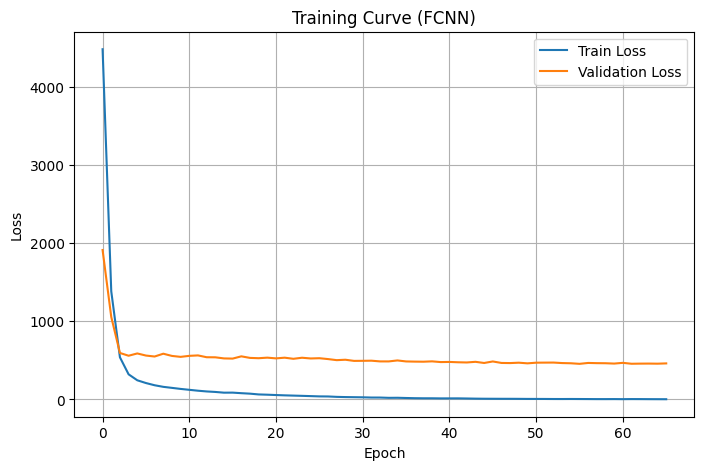

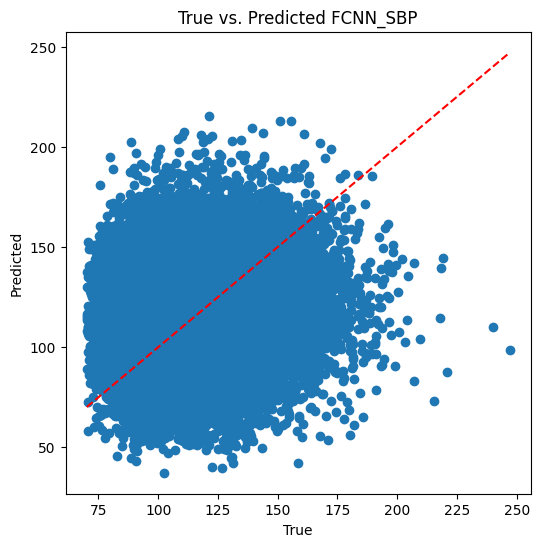

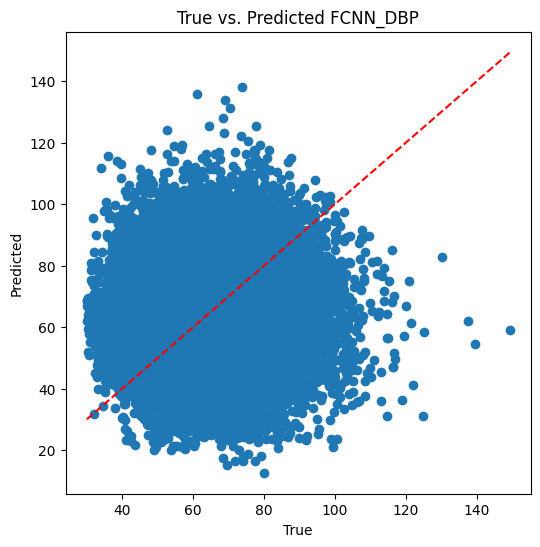

KeyboardInterrupt: 

In [ ]:
model_list = [
    ("FCNN", FCNN),
    ("1D CNN", CNN1D),
    ("RNN", lambda: RNN(model_type='RNN')),
    ("LSTM", lambda: RNN(model_type='LSTM')),
    ("GRU", lambda: RNN(model_type='GRU')),
    ("Transformer", Transformer)
]

for name, model_class in model_list:
    SBP_pred, DBP_pred, SBP_pred_free, DBP_pred_free, train_time, n_epochs, all_training_loss, all_val_loss = evaluate_model(
        name,
        model_class,
        train_loader,
        val_loader,
        test_loader,
        test_loader_free
    )

    y_true = df_calbased[["SBP", "DBP"]].to_numpy(dtype="float32")
    y_pred = np.column_stack([SBP_pred, DBP_pred])
    y_true_free = df_calfree[["SBP", "DBP"]].to_numpy(dtype="float32")
    y_pred_free = np.column_stack([SBP_pred_free, DBP_pred_free])

    metrics = compute_bp_metrics(
        model_name=name,
        split_name="calbased",
        y_true=y_true,
        y_pred=y_pred,
        train_time=train_time,
        n_epochs=n_epochs
    )

    metrics

    metrics_free = compute_bp_metrics(
        model_name=name,
        split_name="calfree",
        y_true=y_true_free,
        y_pred=y_pred_free,
        train_time=train_time,
        n_epochs=n_epochs
    )

    metrics_free

    plt.figure(figsize=(8, 5))
    plt.plot(all_training_loss, label="Train Loss")
    plt.plot(all_val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training Curve ({name})")
    plt.legend()
    plt.grid(True)
    plt.savefig(FIG_DIR / f"{name}_training_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    plot_true_vs_pred(df_calbased["SBP"], SBP_pred, name, "calbased", "SBP")
    plot_true_vs_pred(df_calbased["DBP"], DBP_pred, name, "calbased", "DBP")
    plot_true_vs_pred(df_calfree["SBP"], SBP_pred_free, name, "calfree", "SBP")
    plot_true_vs_pred(df_calfree["DBP"], DBP_pred_free, name, "calfree", "DBP")

    del SBP_pred, DBP_pred, SBP_pred_free, DBP_pred_free, train_time, n_epochs, all_training_loss, all_val_loss, metrics, metrics_free
    gc.collect()